# EDA — car_dataset_v5.1
Goal: look for hidden structure ("hidden features") that explains the large residuals in the linear model.
Uses the same `config.py`. Read-only: nothing here changes the modelling notebook.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import config as C
pd.set_option("display.width", 200, "display.max_columns", 50)
d = pd.read_csv(C.DATA_PATH)
d["log_price"] = np.log(d[C.TARGET])
print(d.shape); d.head()

(30104, 12)


,brand,model,car_type,fuel_type,gear_type,color,engine_capacity,mileage,year,car_age,price,log_price
0,HONDA,CITY,Sedan,Benzine,Automatic,Red,1000,62000,2020,6,419000,12.945626
1,FORD,EVEREST,SUV,Diesel,Automatic,White,2000,130000,2012,14,849000,13.651814
2,HONDA,CIVIC,Hatchback,Benzine,Automatic,Grey,1500,103000,2021,5,759000,13.539757
3,TOYOTA,FORTUNER,PPV,Diesel,Automatic,Black,2800,57000,2022,4,1069000,13.882234
4,TOYOTA,ALPHARD,Van,Benzine,Automatic,White,2500,61800,2022,4,2188000,14.598498


## 1. Basic quality: missing values, duplicates, impossible values

In [2]:
feat = [c for c in d.columns if c not in (C.TARGET, "log_price")]
q = {
    "missing cells": int(d.isna().sum().sum()),
    "duplicate rows (all columns)": int(d.duplicated().sum()),
    "duplicate rows ignoring price (same car, different price)": int(d.duplicated(subset=feat).sum()),
    "car_age == 0": int((d["car_age"] == 0).sum()),
    "mileage <= 10": int((d["mileage"] <= 10).sum()),
    "year + car_age == 2026 for all rows": bool(((d["year"] + d["car_age"]) == 2026).all()),
}
pd.Series(q, name="value").to_frame()

,value
missing cells,0
duplicate rows (all columns),0
"duplicate rows ignoring price (same car, different price)",129
car_age == 0,94
mileage <= 10,47
year + car_age == 2026 for all rows,True


In [3]:
dup = d[d.duplicated(subset=feat, keep=False)].sort_values(feat)
print("example groups of identical cars with different prices:")
dup.head(12)

example groups of identical cars with different prices:


,brand,model,car_type,fuel_type,gear_type,color,engine_capacity,mileage,year,car_age,price,log_price
22774,BMW,330E,Sedan,Hybrid,Automatic,Black,2000,62500,2024,2,1690000,14.340239
28295,BMW,330E,Sedan,Hybrid,Automatic,Black,2000,62500,2024,2,929000,13.741864
13753,BMW,330E,Sedan,Hybrid,Automatic,Black,2000,77500,2020,6,990000,13.805460
13840,BMW,330E,Sedan,Hybrid,Automatic,Black,2000,77500,2020,6,949000,13.763164
15978,BMW,330E,Sedan,Hybrid,Automatic,Black,2000,92500,2018,8,545000,13.208541
17155,BMW,330E,Sedan,Hybrid,Automatic,Black,2000,92500,2018,8,750000,13.527828
13318,BMW,330E,Sedan,Hybrid,Automatic,Black,2000,102500,2017,9,559000,13.233905
16936,BMW,330E,Sedan,Hybrid,Automatic,Black,2000,102500,2017,9,399000,12.896717
12240,BMW,330E,Sedan,Hybrid,Automatic,White,2000,62500,2022,4,1559000,14.259555
19654,BMW,330E,Sedan,Hybrid,Automatic,White,2000,62500,2022,4,1065000,13.878485


## 2. Target: price vs log(price)

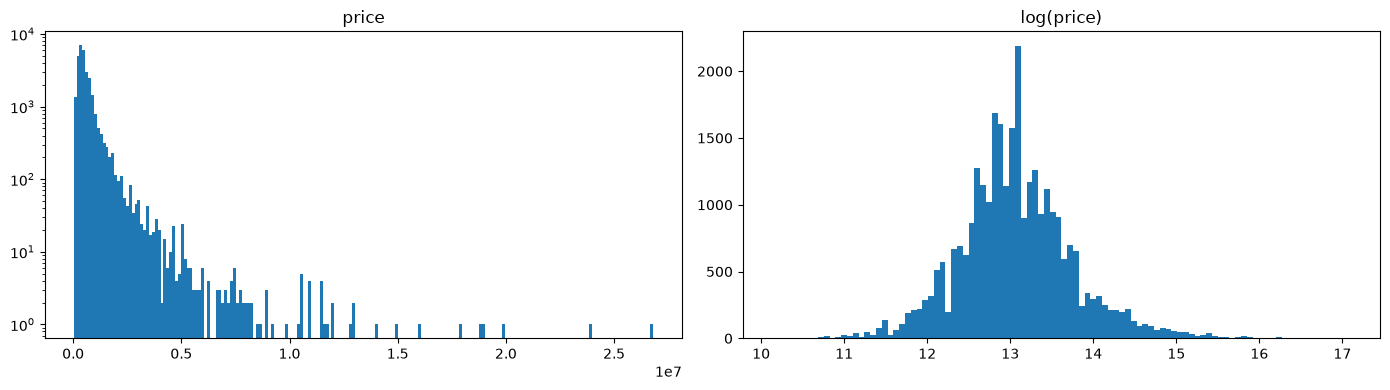

,count,mean,std,min,1%,5%,50%,95%,99%,max
price,30104.0,627637.0,754153.0,25000.0,94000.0,159000.0,459000.0,1590000.0,3490000.0,26800000.0


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].hist(d[C.TARGET], bins=200); ax[0].set_title("price"); ax[0].set_yscale("log")
ax[1].hist(d["log_price"], bins=100); ax[1].set_title("log(price)")
plt.tight_layout(); plt.show()
d[C.TARGET].describe(percentiles=[.01, .05, .5, .95, .99]).round(0).to_frame().T

## 3. Price vs car age — is depreciation monotonic?

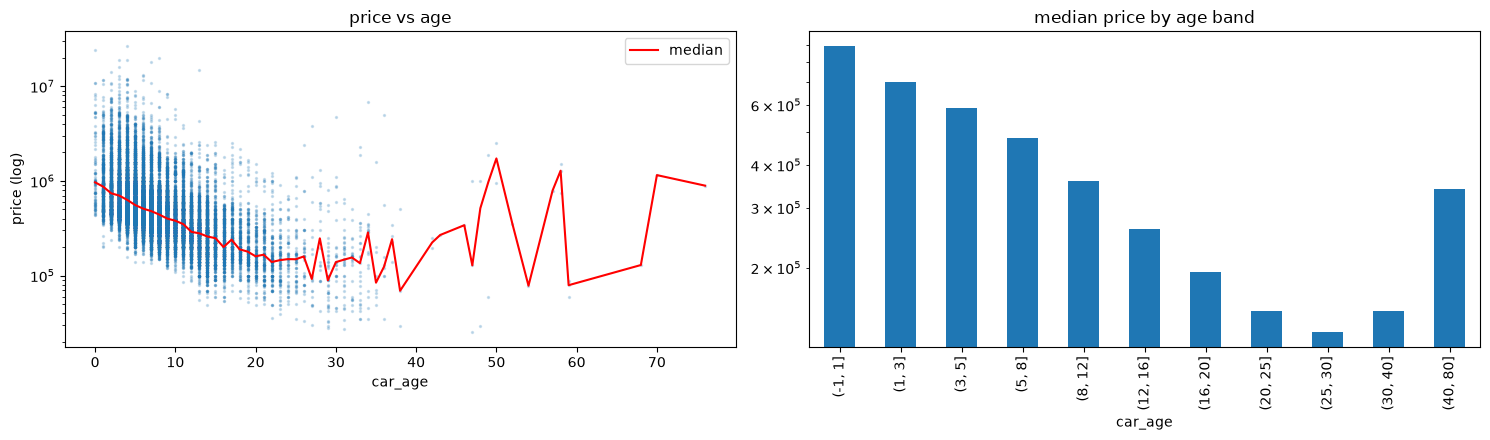

,n,median_price,p90_price
car_age,,,
"(-1, 1]",629,895000.0,3110000.0
"(1, 3]",3375,702000.0,1790000.0
"(3, 5]",6252,589000.0,1390000.0
"(5, 8]",8937,479000.0,899000.0
"(8, 12]",6083,359000.0,699000.0
"(12, 16]",3196,259000.0,499000.0
"(16, 20]",846,194000.0,459000.0
"(20, 25]",499,149000.0,395600.0
"(25, 30]",140,129000.0,599000.0


In [5]:
bins = [-1, 1, 3, 5, 8, 12, 16, 20, 25, 30, 40, 80]
a = d.groupby(pd.cut(d["car_age"], bins), observed=True).agg(n=(C.TARGET, "size"), median_price=(C.TARGET, "median"),
                                                            p90_price=(C.TARGET, lambda s: s.quantile(.9)))
fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
ax[0].scatter(d["car_age"], d[C.TARGET], s=2, alpha=.2); ax[0].set_yscale("log"); ax[0].set_xlabel("car_age"); ax[0].set_ylabel("price (log)")
m = d.groupby("car_age")[C.TARGET].median(); ax[0].plot(m.index, m.values, c="r", label="median"); ax[0].legend(); ax[0].set_title("price vs age")
a["median_price"].plot.bar(ax=ax[1], title="median price by age band"); ax[1].set_yscale("log")
plt.tight_layout(); plt.show()
a

## 4. Mileage encoding — exact km or 5,000-km buckets?

In [6]:
d["mileage_bucketed"] = d["mileage"] % 5000 == 2500      # 2,500 / 7,500 / 12,500 ... = midpoint of a 5k bucket
d["km_per_year"] = d["mileage"] / d["car_age"].clip(lower=1)
print("share of rows with bucketed mileage:", round(100 * d["mileage_bucketed"].mean(), 1), "%")
print("top mileage values:", d["mileage"].value_counts().head(8).to_dict())
print("km/year quantiles:", d["km_per_year"].quantile([.01, .05, .5, .95, .99]).round(0).to_dict())
d.groupby("mileage_bucketed").agg(n=(C.TARGET, "size"), median_age=("car_age", "median"), median_price=(C.TARGET, "median"),
                                  share_mileage_2500=("mileage", lambda m: (m == 2500).mean()))

share of rows with bucketed mileage: 60.6 %
top mileage values: {2500: 1447, 97500: 676, 92500: 578, 102500: 574, 82500: 542, 122500: 494, 87500: 480, 72500: 469}
km/year quantiles: {0.01: 36.0, 0.05: 625.0, 0.5: 14154.0, 0.95: 32831.0, 0.99: 47500.0}


,n,median_age,median_price,share_mileage_2500
mileage_bucketed,,,,
False,11849,7.0,469000.0,0.000000
True,18255,7.0,455000.0,0.079266


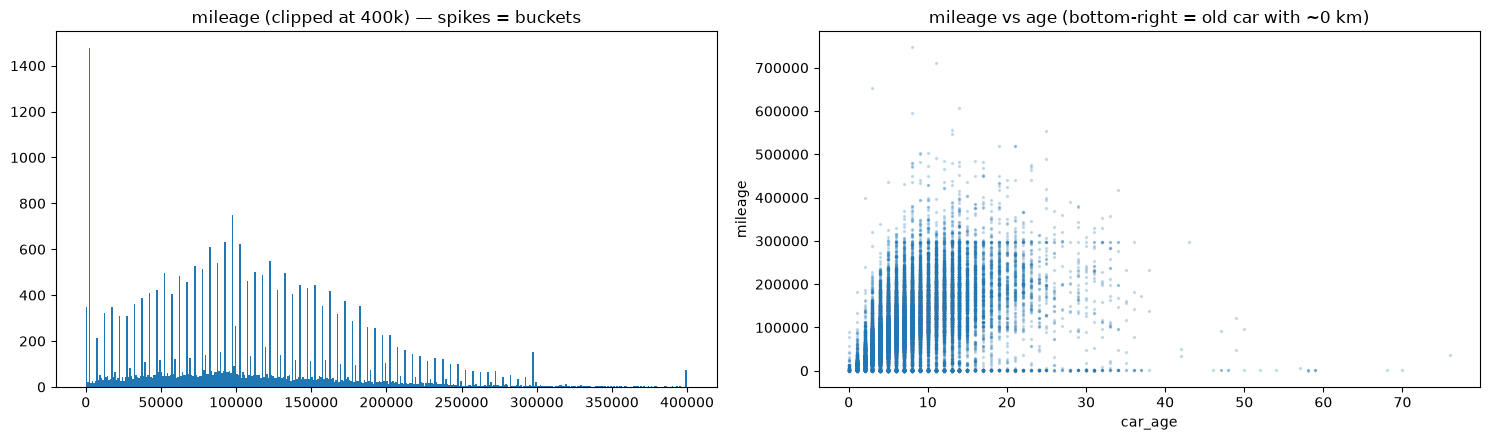

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
ax[0].hist(d["mileage"].clip(upper=400_000), bins=400); ax[0].set_title("mileage (clipped at 400k) — spikes = buckets")
ax[1].scatter(d["car_age"], d["mileage"], s=2, alpha=.2); ax[1].set_xlabel("car_age"); ax[1].set_ylabel("mileage")
ax[1].set_title("mileage vs age (bottom-right = old car with ~0 km)")
plt.tight_layout(); plt.show()

## 5. Row order — does the file contain different sources / periods?

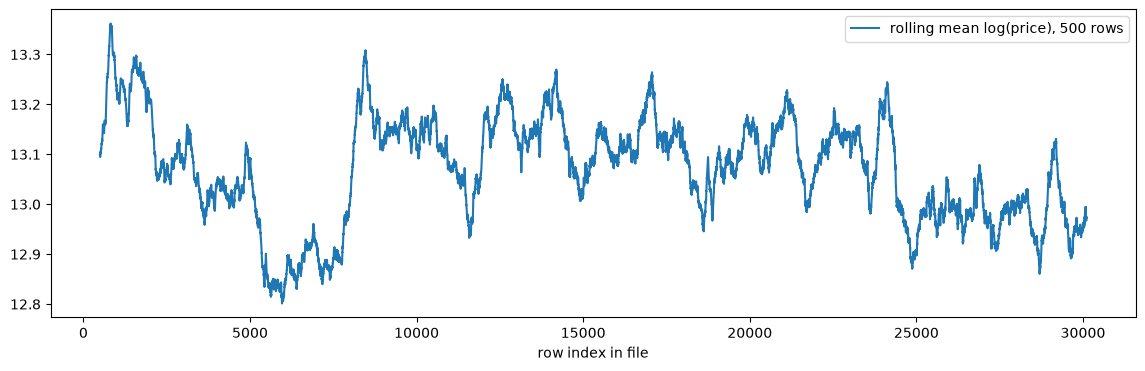

,n,median_price,median_age,pct_bucketed_mileage,pct_age_25plus,pct_luxury_price_3M
row_block,,,,,,
0,3000,529000.0,6.0,0.0,0.4,0.3
1,3000,438000.0,7.0,0.2,1.1,0.4
2,3000,444000.0,7.0,37.2,0.7,0.9
3,3000,479000.0,7.0,79.1,0.8,0.9
4,3000,479000.0,7.0,82.6,0.4,1.7
5,3000,469000.0,7.0,84.8,0.8,1.8
6,3000,459450.0,7.0,81.1,0.8,1.6
7,3000,455000.0,7.0,77.9,1.7,2.5
8,3000,419000.0,8.0,85.1,2.0,1.8


In [8]:
d["row_block"] = d.index // 3000
rb = d.groupby("row_block").agg(n=(C.TARGET, "size"), median_price=(C.TARGET, "median"), median_age=("car_age", "median"),
                                pct_bucketed_mileage=("mileage_bucketed", lambda s: 100 * s.mean()),
                                pct_age_25plus=("car_age", lambda s: 100 * (s >= 25).mean()),
                                pct_luxury_price_3M=(C.TARGET, lambda s: 100 * (s >= 3e6).mean()))
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(d.index, d["log_price"].rolling(500).mean(), label="rolling mean log(price), 500 rows")
ax.set_xlabel("row index in file"); ax.legend(); plt.show()
rb.round(1)

## 6. Categorical features vs log(price)

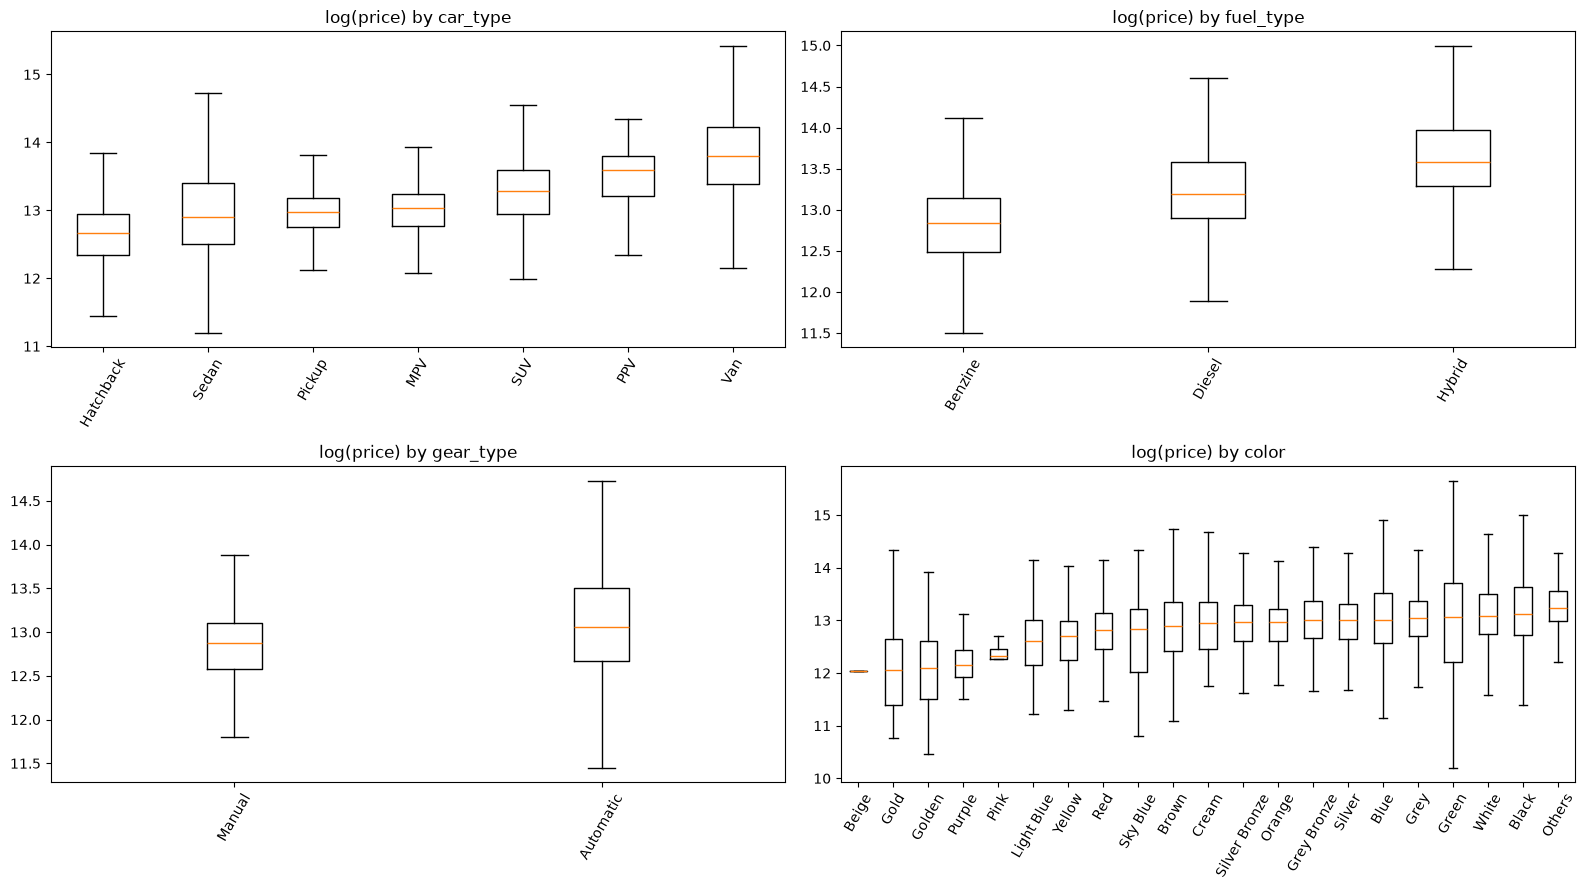

In [9]:
fig, ax = plt.subplots(2, 2, figsize=(16, 9))
for a_, c in zip(ax.ravel(), ["car_type", "fuel_type", "gear_type", "color"]):
    order = d.groupby(c)["log_price"].median().sort_values().index
    a_.boxplot([d.loc[d[c] == k, "log_price"] for k in order], tick_labels=order, showfliers=False)
    a_.tick_params(axis="x", rotation=60); a_.set_title(f"log(price) by {c}")
plt.tight_layout(); plt.show()

In [10]:
# color is suspicious: rare colours may simply mark classic cars
d.groupby("color").agg(n=(C.TARGET, "size"), median_age=("car_age", "median"), median_price=(C.TARGET, "median"),
                       pct_age_25plus=("car_age", lambda s: 100 * (s >= 25).mean())).sort_values("median_age", ascending=False).round(1)

,n,median_age,median_price,pct_age_25plus
color,,,,
Beige,1,22.0,169000.0,0.0
Gold,44,20.0,172000.0,13.6
Cream,43,19.0,420000.0,27.9
Golden,91,19.0,178000.0,15.4
Purple,28,12.5,188500.0,14.3
Brown,688,10.0,398000.0,3.9
Light Blue,171,10.0,299000.0,5.3
Sky Blue,60,9.5,376500.0,3.3
Silver Bronze,1783,8.0,427000.0,1.7


## 7. Depreciation speed differs by brand (median log price by age, top brands)

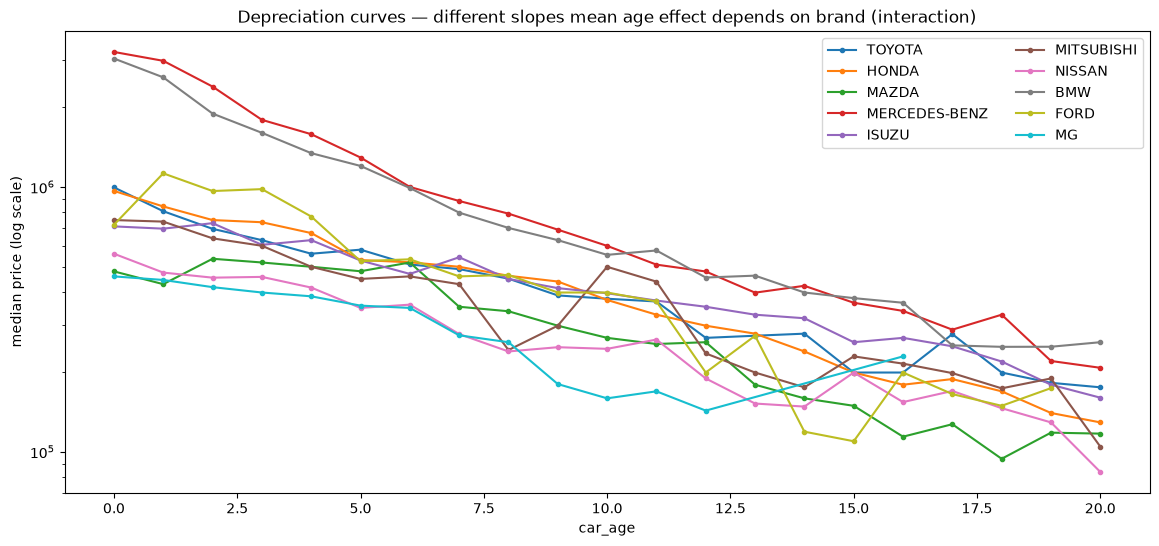

,n,pct_value_lost_per_year
brand,,
VOLVO,200,14.8
MERCEDES-BENZ,1843,13.1
FORD,1215,12.7
BMW,1371,12.2
PORSCHE,219,11.4
MG,789,10.1
MAZDA,2054,9.8
HONDA,5271,8.8
NISSAN,1547,8.5


In [11]:
top = d["brand"].value_counts().head(10).index
fig, ax = plt.subplots(figsize=(14, 6))
for b in top:
    s = d[(d["brand"] == b) & d["car_age"].between(0, 20)].groupby("car_age")["log_price"].median()
    ax.plot(s.index, np.exp(s.values), marker="o", ms=3, label=b)
ax.set_yscale("log"); ax.set_xlabel("car_age"); ax.set_ylabel("median price (log scale)"); ax.legend(ncol=2)
ax.set_title("Depreciation curves — different slopes mean age effect depends on brand (interaction)"); plt.show()

# simple slope per brand: OLS of log price on age within brand (age 0-20, brands >= 200 cars)
rows = []
for b, g in d[d["car_age"].between(0, 20)].groupby("brand"):
    if len(g) >= 200:
        k = np.polyfit(g["car_age"], g["log_price"], 1)[0]
        rows.append(dict(brand=b, n=len(g), pct_value_lost_per_year=round(100 * (1 - np.exp(k)), 1)))
pd.DataFrame(rows).sort_values("pct_value_lost_per_year", ascending=False).set_index("brand")

## 8. Engine capacity & numeric correlations

In [12]:
num = d[["engine_capacity", "mileage", "car_age", "km_per_year", "log_price"]].assign(log_mileage=np.log(d["mileage"]))
num.corr(method="spearman").round(2)

,engine_capacity,mileage,car_age,km_per_year,log_price,log_mileage
engine_capacity,1.00,0.10,0.12,0.01,0.40,0.10
mileage,0.10,1.00,0.52,0.60,-0.35,1.00
car_age,0.12,0.52,1.00,-0.26,-0.59,0.52
km_per_year,0.01,0.60,-0.26,1.00,0.12,0.60
log_price,0.40,-0.35,-0.59,0.12,1.00,-0.35
log_mileage,0.10,1.00,0.52,0.60,-0.35,1.00


## 9. Classic / collector cars (age ≥ 25)

In [13]:
old = d[d["car_age"] >= 25]
print(f"{len(old)} cars ≥ 25 years ({100 * len(old) / len(d):.1f}%)")
old.groupby("brand").agg(n=(C.TARGET, "size"), median_price=(C.TARGET, "median"), max_price=(C.TARGET, "max")).sort_values("n", ascending=False).head(15)

345 cars ≥ 25 years (1.1%)


,n,median_price,max_price
brand,,,
MERCEDES-BENZ,88,169000.0,4990000
TOYOTA,66,109000.0,1599000
HONDA,49,68000.0,3800000
MITSUBISHI,27,179000.0,1090000
BMW,20,179500.0,750000
NISSAN,15,69000.0,1890000
ISUZU,10,145000.0,175000
VOLVO,10,68950.0,159888
JAGUAR,7,650000.0,950000
